In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys,os,re

import pandas            as pd
import seaborn           as sb

from source_code.galdist import galaxy_distribution

import copy
from copy      import deepcopy


import warnings
warnings.filterwarnings('ignore')

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
#Euclid survey specifications, N_gw in [10^5-10^6] according to ET
galaxy_specs = {'fsky': 0.35, 
                'gal_per_arcmin': 30.,
                'sigma_eps': 0.3,  #sigma associated to noise for GC and WL
                'Nbin_ell': 20,
                'lmin': 10,
                'lmax': 1500}

GW_specs = {'fsky': 0.35, 
            'N_gw': 10**5, 
            'sigma_eps_gw': 0.005} #sigma associated to noise (d_L) for GW-WL

analysis_settings = {'Nbin_ell': 20,
                     'lmin': 10,
                     'lmax': 1500}

use_obs  = ['GC', 'WL']


In [3]:
lmin = np.log10(analysis_settings['lmin'])
lmax = np.log10(analysis_settings['lmax'])
N    = analysis_settings['Nbin_ell']

ell_lims = np.logspace(lmin,lmax,N) #creation of array-> N bin log spaced
ells     = np.array([int(ell) for ell in 0.5*(ell_lims[:-1]+ell_lims[1:])]) 
#evaluation of middle points of each bin 
deltas   = (ell_lims[1:]-ell_lims[:-1]) #evaluation of the amplitude of each bin

In [4]:
#Cosmological parameters describing the LCDM Universe
fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'ns': 0.96,
            'As': 2.12605e-09,
            'tau': 0.05,
            'H0': 67.,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            'a0': - 0.007589,
            'a1' :  0.002008,
            'a2' : - 0.004127,
            'a3' :  0.002918,
            'a4' : -0.0006784,
            'omegab': 0.05,
            'sigma8': 0.84,
            'omegam' : 0.31,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292}
stability_flag ={
                    'EFT_ghost_math_stability'   : False,
                    'EFT_mass_math_stability'    : False,
                    'EFT_ghost_stability'        : False,
                    'EFT_gradient_stability'     : False,
                    'EFT_mass_stability'         : False,
                    'EFT_additional_priors'      : False,
                    }
    
EFT_params_alpha = {'EFTflag':1,
                  'PureEFTmodel':1,
                  'PureEFTmodelOmega':3,
                  'EFTOmega0':-0.019,
                  'EFTOmegaExp':0.66}
EFT_params_alpha.update(stability_flag)

param_labels=['$H_0$','$\Omega_b h^2$','$\Omega_c h^2$', r'$n_s$', r'$A_s$']



In [5]:
distributions = np.load('./mock_data/MG_test_galonly_IApoly_source_distribution.npy',allow_pickle=True).item()


In [6]:
if 'GC' in distributions:
    Nbins_gc=distributions['GC']['Nbins']

if 'WL' in distributions:
    Nbins_wl=distributions['WL']['Nbins']

numbins = max(Nbins_gc, Nbins_wl)

obs=[]
if 'GC' in use_obs:
    obs.append('G')

if 'WL' in use_obs:
    obs.append('L')

In [7]:

case='simple'
extra={}
camb_path = '/users/chiaradeleo/Desktop/myeftcamb-main/' 


In [8]:
#from source_code.fisher import get_Fisher
#fisher = get_Fisher(fiducial, free_params, ells, deltas, distributions, obs_settings, galaxy_specs).fisher_matrix()


In [9]:
#covmat=get_Fisher(fiducial, free_params, ells, deltas, distributions, obs_settings, galaxy_specs).compute_covmat()
#for ell,i in enumerate(ells):
 #   plt.figure()
  #  plt.title(r'Covariance matrix at $\ell={}$'.format(int(i)))
   # sb.heatmap(covmat[ell],norm=LogNorm());

In [10]:
obs_settings_EFT={'extra': extra,
             'case': case,
             'camb_path': camb_path}


In [11]:
#fisher_EFT = get_Fisher(fiducial, free_params, ells, deltas, distributions, obs_settings_EFT, galaxy_specs).fisher_matrix()


In [12]:
#from source_code.plot import plotter

#fishers=[fisher,fisher_EFT]
#fisher_labels=['LCDM', 'EFT']
#plotter(fiducial, params, param_labels, fishers, param_names, fisher_labels)

In [13]:

free_params =  {#'EFTOmega0':0.1,
                #'EFTOmegaExp':0.1,
                'H0': 0.3,
                'ombh2': 0.3,
                'omch2': 0.3,
                'ns':0.3,
                'As':0.3}
param_names = list(free_params.keys())

params = [ fiducial[name] for name in param_names ] #EFT_params_alpha[name] if name in EFT_params_alpha else 
#print(param_names)

In [14]:
from source_code.fisher_for_eft import get_Fisher
fisher_alpha = get_Fisher(fiducial, free_params, ells, deltas, distributions, obs_settings_EFT, galaxy_specs).fisher_matrix()
np.savetxt('fisher_matrix.txt', fisher_alpha)


['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']
['/users/chiaradeleo/Desktop/myeftcamb-main/camb']


In [19]:
params = ['$H_0$', '$\Omega_b h^2$', '$\Omega_c h^2$', '$n_s$', '$A_s$']

# Convert the Fisher matrix to a DataFrame with the parameter labels
df = pd.DataFrame(fisher_alpha, columns=params)

# Save the DataFrame to a .txt file with space-separated values
df.to_csv('fisher_matrix.txt', sep=' ', header=True, index=True)

In [16]:
###NOT POSITIVE DEFINITE
file_path = 'covariance_matrix.covmat'
covmat=np.linalg.inv(fisher_alpha)
header = ' '.join(param_names)

np.savetxt('covariance_matrix.covmat', covmat, header=header)

eigenvalues = np.linalg.eigvals(covmat)


positive_definite = np.all(eigenvalues > 0)


print("Eigenvalues:", eigenvalues)
print("Is the matrix positive definite?", positive_definite)

Eigenvalues: [ 1.49127130e-02  4.72777856e-06 -7.35439605e-08  6.04810607e-08
  3.28003438e-25]
Is the matrix positive definite? False


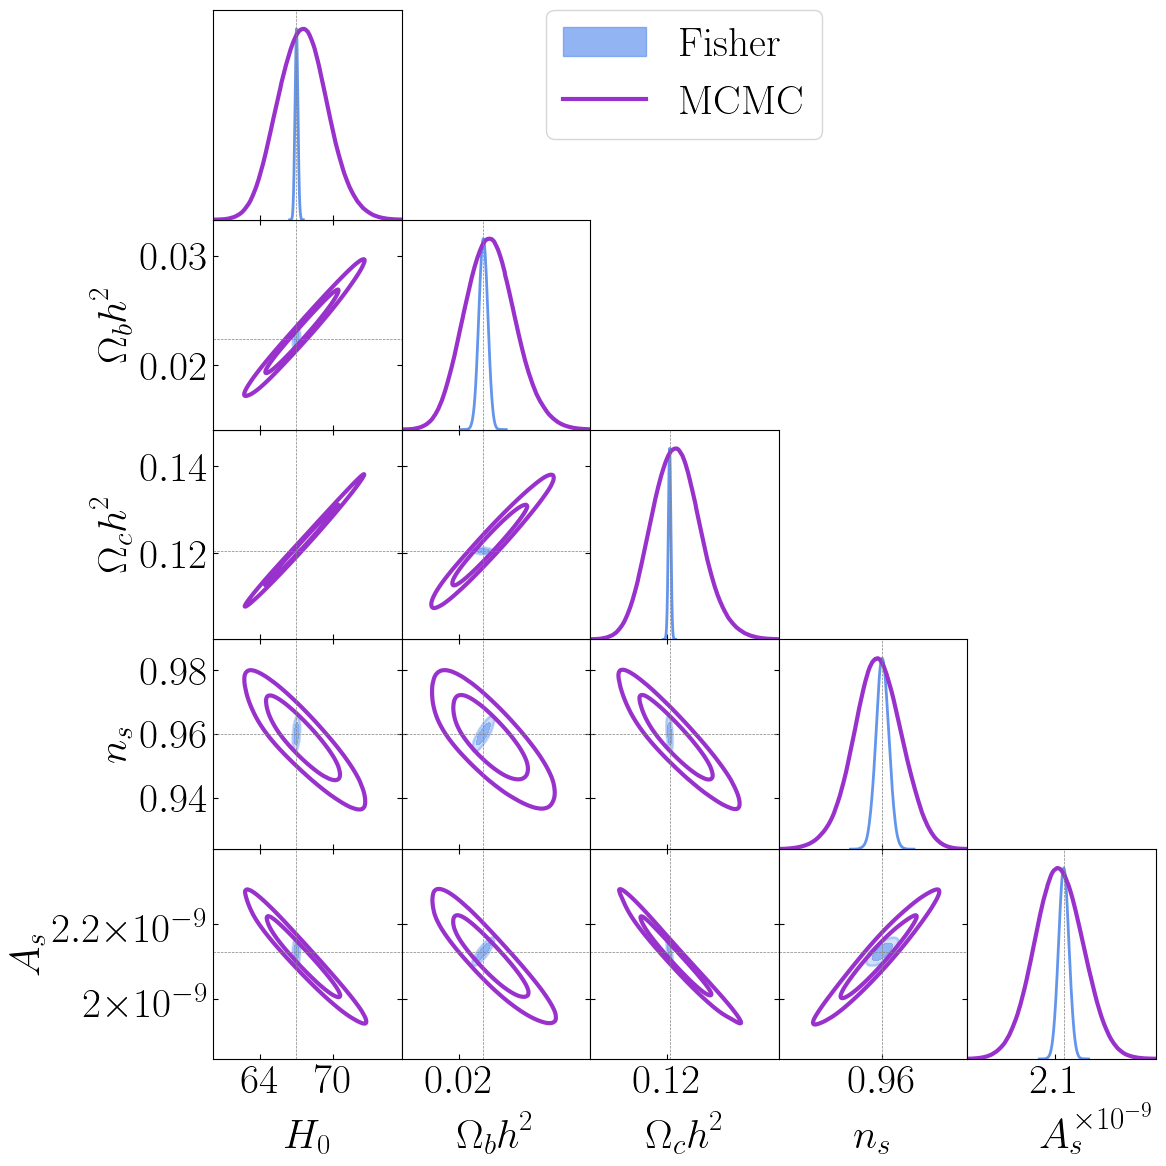

In [17]:
from source_code.plot import plotter
from scipy.linalg import inv
fishers={'fisher':fisher_alpha}
#print()
fisher_labels=['EFT']

plotter(fiducial,obs_settings_EFT, params, param_labels, fishers, param_names, fisher_labels)